In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [8]:
df = pd.read_csv("cleaned_statsfinal.csv")

print("Dataset loaded successfully!")
print(df.head())
print("\nShape:", df.shape)

Dataset loaded successfully!
   Unnamed: 0        Date  Q-P1  Q-P2  Q-P3  Q-P4      S-P1      S-P2  \
0           0  2010-06-13  5422  3725   576   907  17187.74  23616.50   
1           1  2010-06-14  7047   779  3578  1574  22338.99   4938.86   
2           2  2010-06-15  1572  2082   595  1145   4983.24  13199.88   
3           3  2010-06-16  5657  2399  3140  1672  17932.69  15209.66   
4           4  2010-06-17  3668  3207  2184   708  11627.56  20332.38   

       S-P3      S-P4  Total_Sales  Total_Quantity  
0   3121.92   6466.91     50393.07           10630  
1  19392.76  11222.62     57893.23           12978  
2   3224.90   8163.85     29571.87            5394  
3  17018.80  11921.36     62082.51           12868  
4  11837.28   5048.04     48845.26            9767  

Shape: (4600, 12)


In [9]:
# Target variable
target = "Total_Sales"

# Input features
X = df.drop(columns=[target])

# Output/target
y = df[target]

print("Input features:")
print(X.columns.tolist())

print("\nTarget variable:")
print(target)

Input features:
['Unnamed: 0', 'Date', 'Q-P1', 'Q-P2', 'Q-P3', 'Q-P4', 'S-P1', 'S-P2', 'S-P3', 'S-P4', 'Total_Quantity']

Target variable:
Total_Sales


In [10]:
X = pd.get_dummies(X, drop_first=True)

print("Features after encoding:")
print(X.head())

Features after encoding:
   Unnamed: 0  Q-P1  Q-P2  Q-P3  Q-P4      S-P1      S-P2      S-P3      S-P4  \
0           0  5422  3725   576   907  17187.74  23616.50   3121.92   6466.91   
1           1  7047   779  3578  1574  22338.99   4938.86  19392.76  11222.62   
2           2  1572  2082   595  1145   4983.24  13199.88   3224.90   8163.85   
3           3  5657  2399  3140  1672  17932.69  15209.66  17018.80  11921.36   
4           4  3668  3207  2184   708  11627.56  20332.38  11837.28   5048.04   

   Total_Quantity  ...  Date_2023-01-25  Date_2023-01-26  Date_2023-01-27  \
0           10630  ...            False            False            False   
1           12978  ...            False            False            False   
2            5394  ...            False            False            False   
3           12868  ...            False            False            False   
4            9767  ...            False            False            False   

   Date_2023-01-28  Date_

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3680, 4583)
Testing data: (920, 4583)


In [12]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [13]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred[:10])

Predictions:
[70173.95999994 43378.7900001  44519.61000002 42965.80000013
 71677.27999993 37847.83999996 56864.73999998 39510.31000006
 69347.83999993 51547.20999995]


In [14]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Regression Model Results")
print("------------------------")
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

Regression Model Results
------------------------
MAE: 6.702453981194159e-08
RMSE: 8.269709464013443e-08
R² Score: 1.0


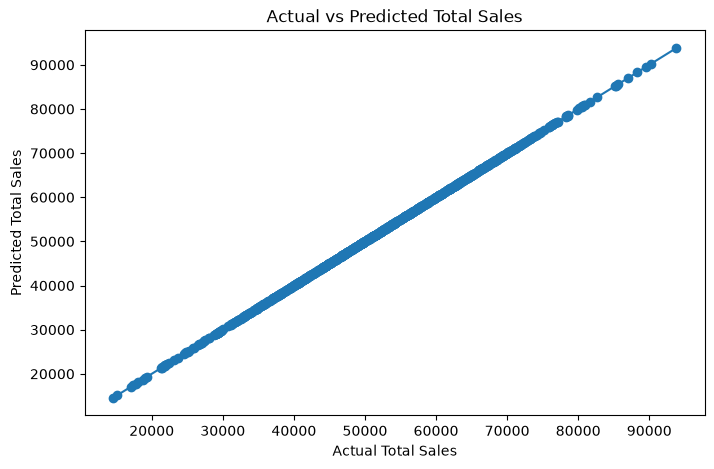

In [15]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Total Sales")
plt.ylabel("Predicted Total Sales")
plt.title("Actual vs Predicted Total Sales")

# Perfect prediction line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot([min_value, max_value], [min_value, max_value])

plt.show()

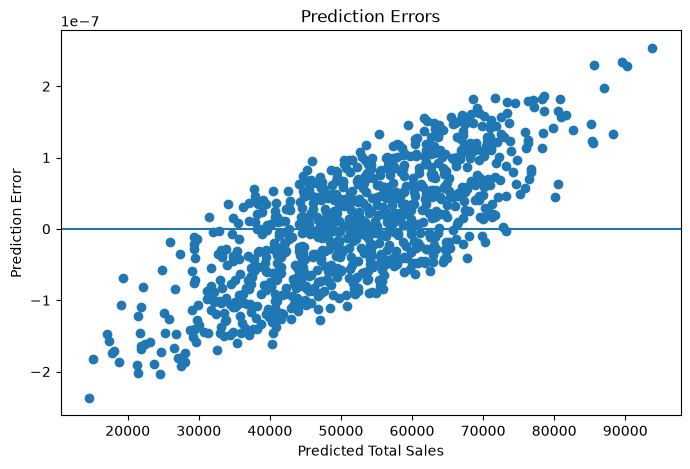

In [16]:
errors = y_test - y_pred

plt.figure(figsize=(8, 5))

plt.scatter(y_pred, errors)

plt.axhline(y=0)

plt.xlabel("Predicted Total Sales")
plt.ylabel("Prediction Error")
plt.title("Prediction Errors")

plt.show()

In [17]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients["Absolute_Coefficient"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

print(coefficients)

              Feature  Coefficient  Absolute_Coefficient
8                S-P4     0.891511              0.891511
6                S-P2     0.875923              0.875923
7                S-P3     0.851371              0.851371
5                S-P1     0.723438              0.723438
9      Total_Quantity     0.648488              0.648488
...               ...          ...                   ...
3729  Date_2020-09-25     0.000000              0.000000
3759  Date_2020-10-25     0.000000              0.000000
3733  Date_2020-09-29     0.000000              0.000000
3415  Date_2019-11-12     0.000000              0.000000
4507  Date_2022-11-19     0.000000              0.000000

[4583 rows x 3 columns]


# Day 12 — Regression Modeling

## Objective

The objective of this task was to build a Linear Regression model to predict continuous numerical values.

## 1. Input and Output

`Total_Sales` was selected as the target variable.

The remaining features were used as input variables.

## 2. Linear Regression

Linear Regression was selected as the baseline regression algorithm.

The model was trained using 80% of the dataset and tested using the remaining 20%.

## 3. Predictions

The trained model generated predictions for Total Sales on the test dataset.

## 4. Prediction Accuracy

The model was evaluated using:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² Score

Lower MAE and RMSE indicate smaller prediction errors, while a higher R² generally indicates a better fit.

## 5. Visualization

Actual vs Predicted values were plotted to understand prediction performance.

Prediction errors were also visualized to identify patterns and unusual errors.

## 6. Model Coefficients

The Linear Regression coefficients were examined to understand the relationship between input features and predicted Total Sales.

A positive coefficient indicates a positive relationship with the prediction, while a negative coefficient indicates a negative relationship, holding other inputs constant.

## Conclusion

Linear Regression provided a baseline model for predicting Total Sales. The evaluation metrics and visualizations help assess how accurately the model captures relationships in the dataset.

In [18]:
prediction_results = pd.DataFrame({
    "Actual_Total_Sales": y_test.values,
    "Predicted_Total_Sales": y_pred,
    "Error": y_test.values - y_pred
})

prediction_results.to_csv("regression_predictions.csv", index=False)

print("Regression predictions saved successfully!")

Regression predictions saved successfully!


In [19]:
coefficients.to_csv("regression_coefficients.csv", index=False)

print("Regression coefficients saved successfully!")

Regression coefficients saved successfully!
